# Data Features Selection
This notebook is the base for features  selection
## Used libraries

In [9]:
# type: ignore
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
from time import time
import shap
import tables 

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE, SelectKBest, SelectFromModel, f_classif, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import cross_val_score 
from sklearn.isotonic import spearmanr
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.feature_selection import RFE


from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.multitest import multipletests


## Loading data
- Cleaning infinite values and NaNs after the previous feature augmentation
- Looking for potential highly correlated features

In [2]:
train = pd.read_parquet('../train_extended.parquet')
test = pd.read_parquet('../test_extended.parquet')

## Feature selection
Several approch were used here :
- Trees Feature Importance
- RFE
- Statistical test
- Dimension reduction
- SFS

In [4]:
x_train, y_train = train.drop('RET', axis=1), train['RET']

In [5]:
ret_cols = ['RET_%d' % i for i in range(1, 6)]
volume_cols = ['VOLUME_%d' % i for i in range(1, 6)]
id_cols = ['DATE', 'STOCK']
cat_cols = ['INDUSTRY','INDUSTRY_GROUP','SECTOR','SUB_INDUSTRY']
# using regex to filter temporal and sectorial aggregation features
DATE_cols = x_train.filter(regex='\w+_\d+_DATE_\w+').columns.tolist()
SECTOR_cols = x_train.filter(regex='\w+_\d+_SECTOR_\w+').columns.tolist()
STOCK_cols = x_train.filter(regex='\w+_\d+_STOCK_\w+').columns.tolist()
INDUSTRY_cols = x_train.filter(regex='\w+_INDUSTRY_\w+').columns.tolist()

# other patterns to filter the others features
ROLLING_STATS_cols = x_train.columns[x_train.columns.str.endswith('D')].tolist()
WEEK_cols = x_train.columns[x_train.columns.str.contains('WEEK')].tolist()
VOLATILITY_cols = x_train.columns[x_train.columns.str.contains('VOLATILITY')].tolist()
OTHER_INDICATOR_cols = list( set(x_train.columns) - set(id_cols + ret_cols + volume_cols + cat_cols + DATE_cols + SECTOR_cols + STOCK_cols + INDUSTRY_cols + ROLLING_STATS_cols + WEEK_cols + VOLATILITY_cols ) - set([f'RET_{i}' for i in range(6, 21)] + [f'VOLUME_{i}' for i in range(6,21)]) )

In [5]:
features = list( set(ret_cols + volume_cols + DATE_cols + SECTOR_cols + STOCK_cols + INDUSTRY_cols + ROLLING_STATS_cols + WEEK_cols + VOLATILITY_cols + OTHER_INDICATOR_cols) )

### Statistical analysis
- Correlations 
- Mutual information
- Information coefficient
- Feature importance
- SHAP Values

#### Correlations

In [28]:
def correlation_features(train, features):
    X = train[features]
    corr_common = X.corr(method='spearman')
    mask = np.triu(np.ones_like(corr_common, dtype=bool))
    fig, ax = plt.subplots(figsize=(22, 18))
    cmap = sns.diverging_palette(10, 220, as_cmap=True)

    heatmap = sns.heatmap(corr_common, mask=mask, cmap=cmap, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})

    fig.tight_layout()
    clustermap = sns.clustermap(corr_common, cmap=cmap, figsize=(15, 15))
    corr_ = corr_common.stack().reset_index()
    corr_.columns = ['x1', 'x2', 'rho']
    corr_ = corr_[corr_.x1!=corr_.x2].drop_duplicates('rho')

    corr_.sort_values('rho', ascending=False)

    return corr_, clustermap, heatmap

In [6]:
def correlation_target(train, features):
    X = train[features]
    y = train['RET']
    corr_target = X.corrwith(y, method='spearman')
    corr_target = corr_target.sort_values(ascending=False)
    return corr_target

<Axes: >

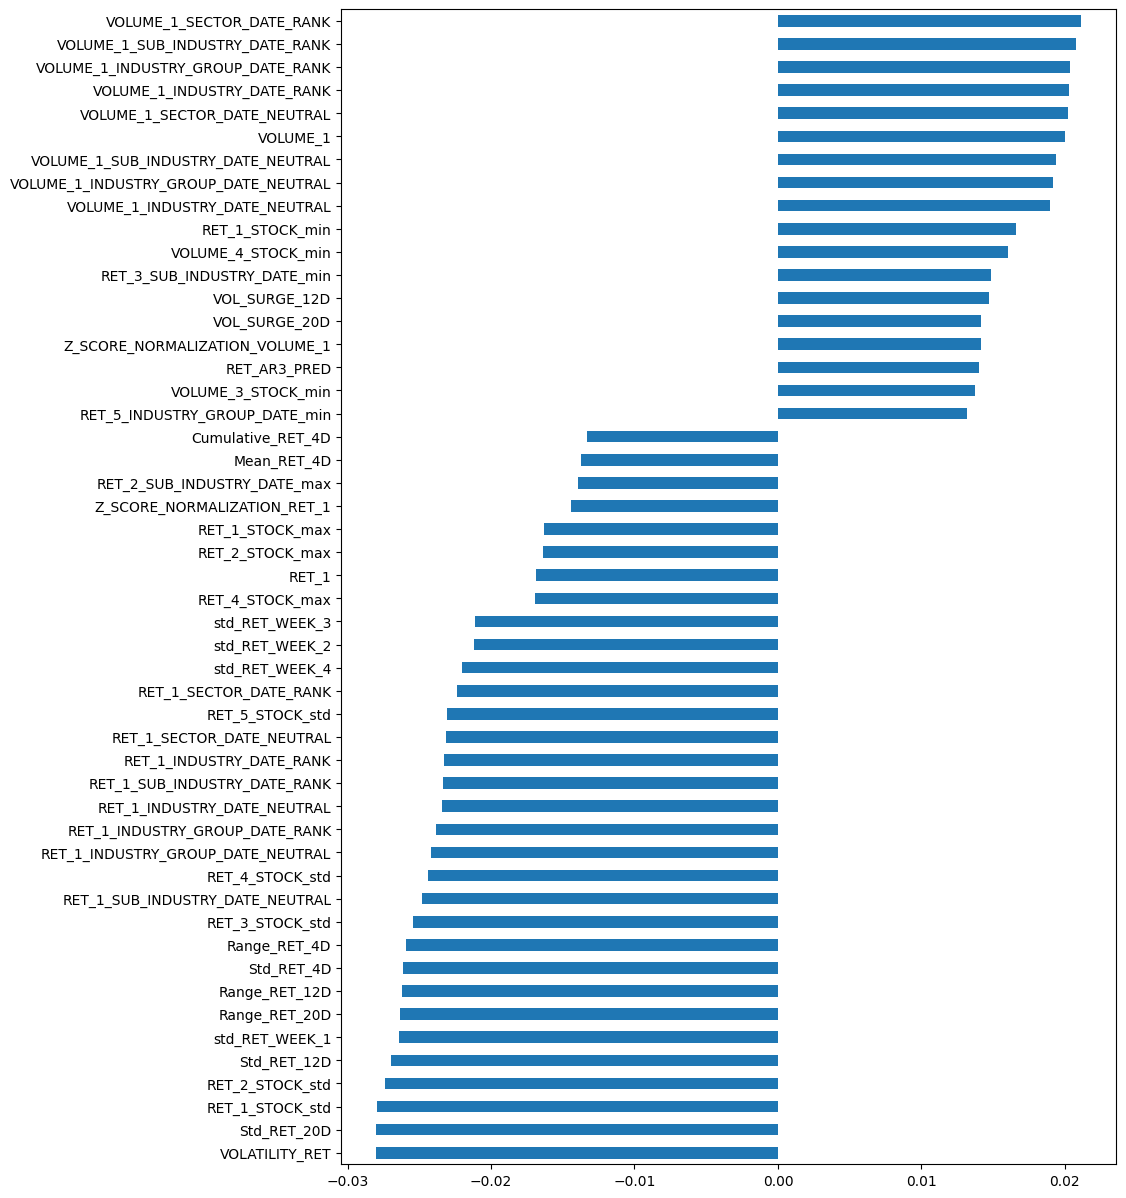

In [7]:
fwd_corr = correlation_target(train, features)
top50 = fwd_corr.abs().nlargest(50).index
fwd_corr.loc[top50].sort_values().plot.barh(figsize=(10, 15), legend=False)

In [8]:
fwd_corr.to_hdf('features_statistics.h5', key='fwd_corr')

#### Mutual Information

In [9]:
# warning ignore
import warnings
warnings.filterwarnings('ignore')

100%|██████████| 692/692 [05:42<00:00,  2.02it/s]


<Axes: >

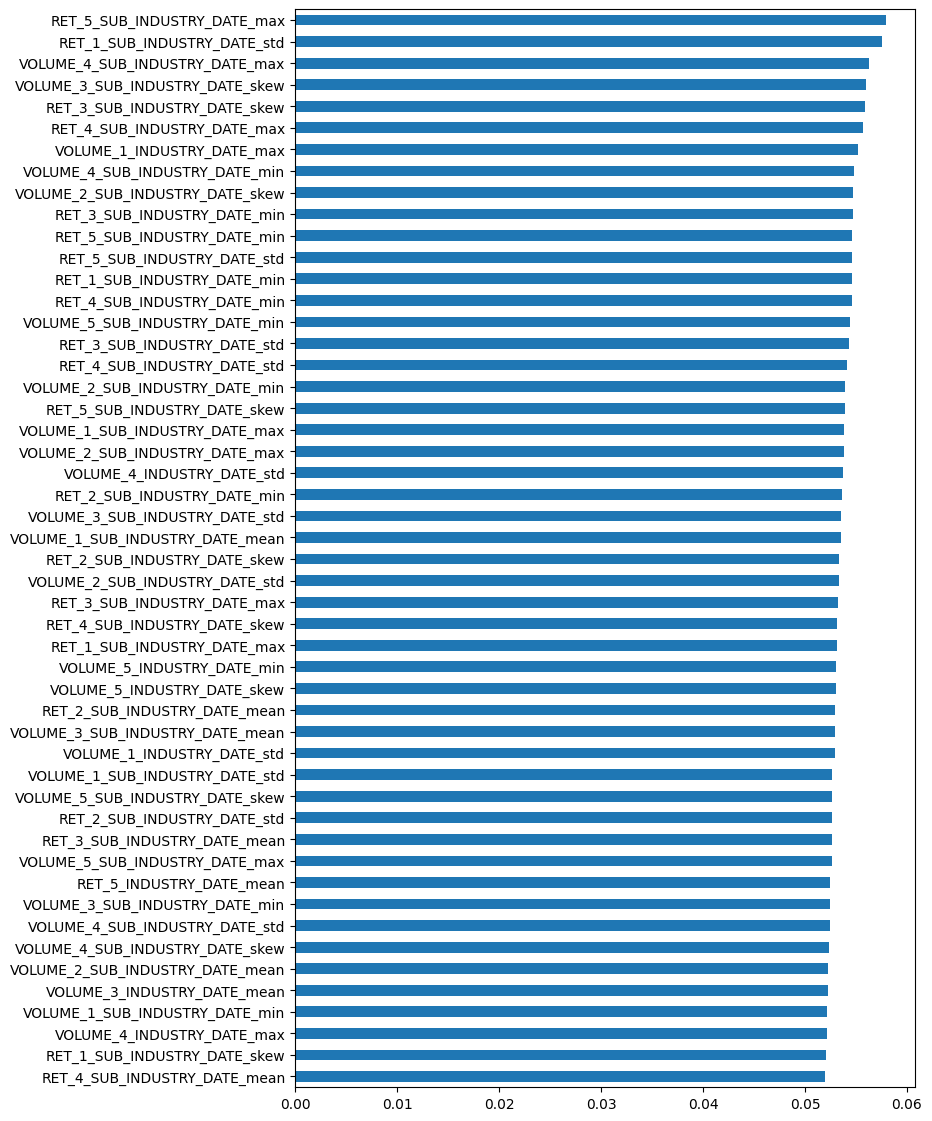

In [10]:
mi = {}
for feature in tqdm(features):
    df = (train.loc[:, ['RET', feature]].dropna().sample(n=100000))
    discrete_features = df[feature].nunique() < 10
    mi[feature] = mutual_info_classif(X=df[[feature]],y=df.RET,discrete_features=discrete_features)[0]
mi = pd.Series(mi)
mi.nlargest(50).sort_values().plot.barh(figsize=(8, 14))


In [11]:
mi.to_hdf('features_statistics.h5', key='mi')

#### RandomForest Feature Importance

In [13]:
def feature_importance(model, features, x_train, y_train):
    X = x_train[features]
    y = y_train
    model.fit(X, y)
    fi = pd.Series(model.feature_importances_, index=features)
    return fi

In [16]:
regularized_model = RandomForestClassifier(
    n_estimators=600,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    verbose=1
)

fi = feature_importance(regularized_model, features, x_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   45.8s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed: 12.7min finished


<Axes: >

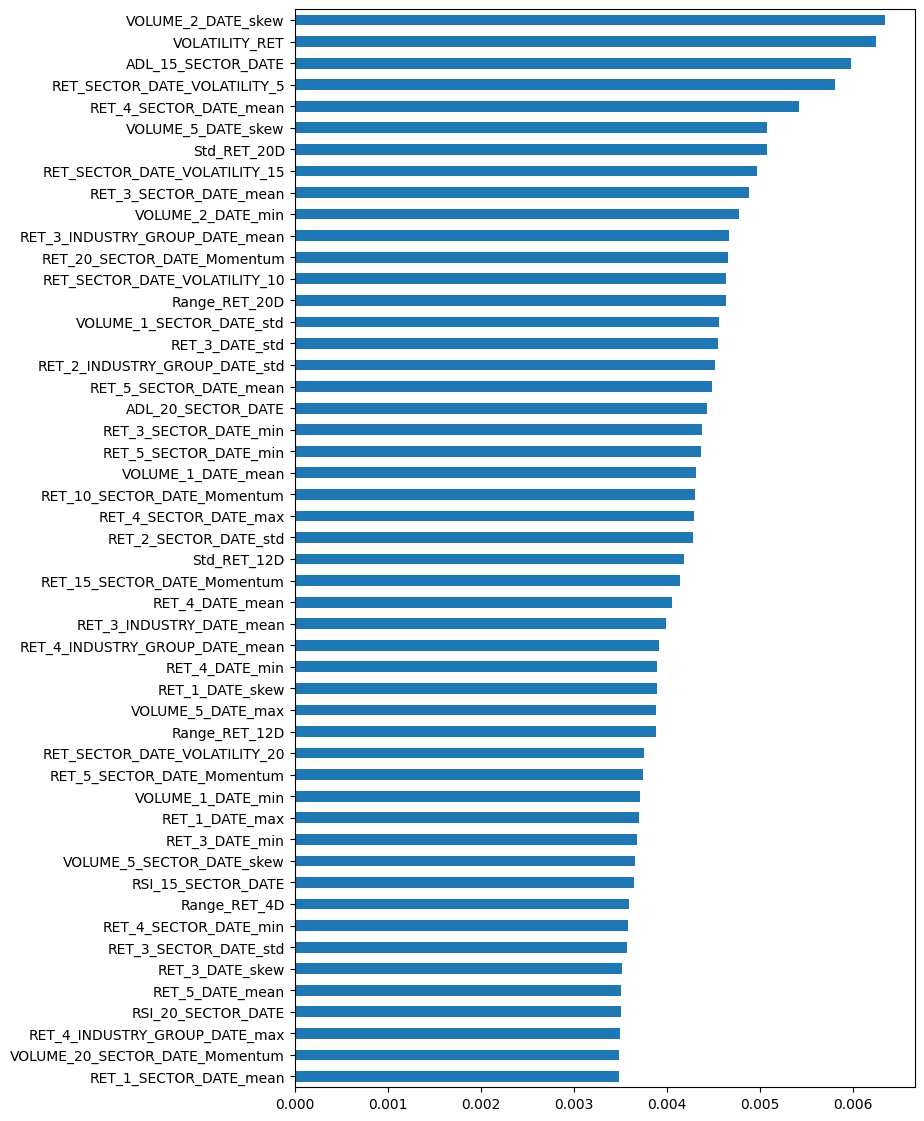

In [17]:

fi.nlargest(50).sort_values().plot.barh(figsize=(8, 14))
 

In [18]:
fi.to_hdf('features_statistics.h5', key='fi')

#### SHAP values

In [ ]:
def shap_values(model, features, x_train, y_train):
    shap.initjs()
    X = x_train[features]
    y = y_train
    model.fit(X, y)
    print('Model trained')
    explainer = shap.TreeExplainer(model)
    print('Explainer created')
    shap_values = explainer.shap_values(X, y, approximate=True, check_additivity=False)
    print('SHAP values calculated')
    shap.summary_plot(shap_values, X)
    plt.gcf().suptitle('SHAP Values')
    plt.gcf().tight_layout()
    return shap_values

In [ ]:
shap_values = shap_values(RandomForestClassifier(n_estimators=10, n_jobs=-1, verbose=1), features, x_train, y_train)

#### Summary

In [3]:
# reading all the statistics in h5 file 'features_statistics.h5'
mi = pd.read_hdf('features_statistics.h5', key='mi')
fi = pd.read_hdf('features_statistics.h5', key='fi')
fwd_corr = pd.read_hdf('features_statistics.h5', key='fwd_corr')

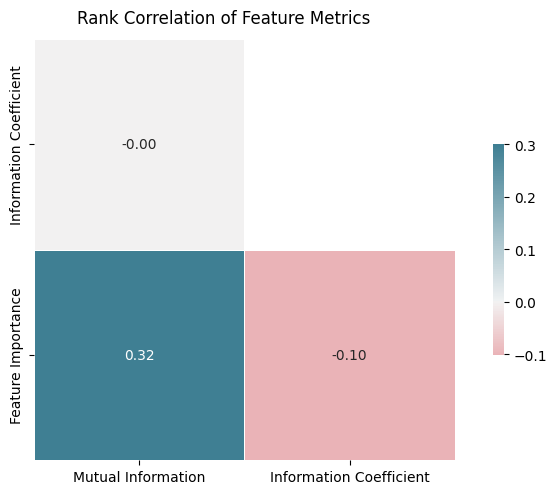

In [20]:

stats = (mi.to_frame('Mutual Information')
         .join(fwd_corr.to_frame('Information Coefficient'))
         .join(fi.to_frame('Feature Importance')))

cols = {'Information Coefficient': stats['Information Coefficient'].abs()}
corr = stats.assign(**cols).corr('spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
corr = corr.iloc[1:, :-1]
mask = mask[1:, :-1]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt='.2f')
plt.xticks(rotation=0)
fig.suptitle('Rank Correlation of Feature Metrics', fontsize=12)
fig.tight_layout()
fig.subplots_adjust(top=.92)


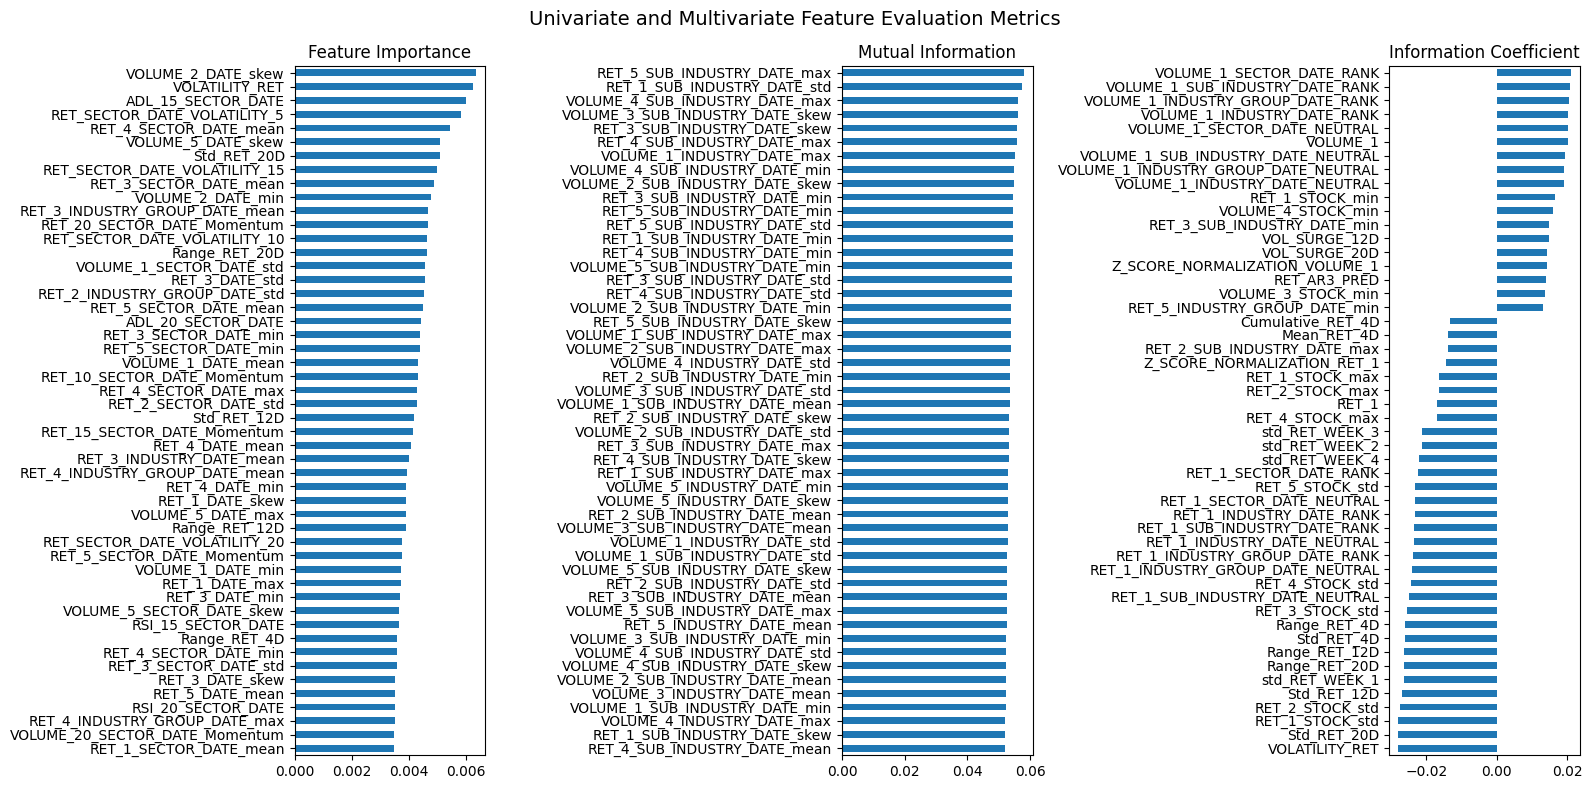

In [21]:
top_n = 50
fig, axes = plt.subplots(ncols=3, figsize=(16, 8))

fi.nlargest(top_n).sort_values().plot.barh(ax=axes[0], title='Feature Importance')
mi.nlargest(top_n).sort_values().plot.barh(ax=axes[1], title='Mutual Information')

top_corr = fwd_corr.abs().nlargest(top_n).index
fwd_corr.loc[top_corr].sort_values().plot.barh(ax=axes[2], title='Information Coefficient')

fig.suptitle('Univariate and Multivariate Feature Evaluation Metrics', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=.91)

### Sequential (forward/backward) Feature Selection 

In [ ]:
candidates = list(set(fi.nlargest(100).index) & set(fwd_corr.abs().nlargest(100).index))
candidates, len(candidates)

(['Std_RET_4D',
  'Std_RET_20D',
  'VOLATILITY_RET',
  'Range_RET_20D',
  'Range_RET_12D',
  'Std_RET_12D',
  'RET_4_SECTOR_DATE_min',
  'RET_5_SECTOR_DATE_min',
  'VOLUME_2_SECTOR_DATE_skew',
  'RET_3_INDUSTRY_GROUP_DATE_min',
  'std_RET_WEEK_1',
  'RET_1_STOCK_std',
  'Range_RET_4D',
  'RET_4_STOCK_std',
  'RSI_20_SECTOR_DATE',
  'RET_2_STOCK_std',
  'RET_5_INDUSTRY_GROUP_DATE_min'],
 17)

In [24]:

# Sequential Feature Selector

def sequential_feature_selector(candidates_features, train, n_features_to_select=1):
    X = train[candidates_features]
    y = train['RET']

    model = RandomForestClassifier(n_estimators=200, max_depth=6, n_jobs=-1, verbose=1)
    sfs = SequentialFeatureSelector(model, n_features_to_select=n_features_to_select, scoring='accuracy', direction='forward', n_jobs=-1, cv=3)
    sfs.fit(X, y)

    selectedFeatures = X.columns[sfs.get_support()]
    return selectedFeatures

In [26]:
selectedFeatures = sequential_feature_selector(candidates, train, 10)
selectedFeatures

Index(['Std_RET_4D', 'Std_RET_20D', 'VOLATILITY_RET', 'Range_RET_12D',
       'Std_RET_12D', 'RET_3_INDUSTRY_GROUP_DATE_min', 'RET_1_STOCK_std',
       'Range_RET_4D', 'RET_4_STOCK_std', 'RET_2_STOCK_std'],
      dtype='object')

### Incremental Feature Selection

In [13]:
def incremental_selection_features(model, train, start_features, candidates_features):
    """
    Incremental feature selection using a given model.

    Parameters:
    - model: Classifier or regressor object.
    - train: Training dataset (pd.DataFrame).
    - start_features: List of features to start with.
    - candidate_features: List of candidate features to test.

    Returns:
    - selected_features: List of selected features.
    - scores: List of cross-validation scores.
    """

    # Initialize variables 
    
    selected_features = start_features.copy()
    rejected_features = []
    
    X = train[selected_features]
    y = train['RET']
    
    best_score = cross_val_score(model, X, y, cv=3, scoring='accuracy').mean()
    print(f'initial score: {best_score}')

    # Iterate over candidate features
    for feature in tqdm(candidates_features):

        # Add feature to selected features
        selected_features.append(feature)

        # Extract training data
        X = train[selected_features]
        
        # Compute cross-validation score
        score = cross_val_score(model, X, y, cv=3, scoring='accuracy').mean()

        # Remove feature if score is not improved
        if score <= best_score:
            selected_features.remove(feature)
            rejected_features.append(feature)
        else:
            best_score = score
            print(f'new best score: {best_score}')

    added_features = list(set(selected_features) - set(start_features))

    return selected_features, added_features, rejected_features, best_score

In [9]:
start_features = pd.read_hdf('features_statistics.h5', key='features_s').to_list()
rejected_features = ['Range_RET_20D', 'RET_2_STOCK_max', 'RET_3_INDUSTRY_GROUP_DATE_mean', 'ADL_10_SECTOR_DATE', 'VOLUME_1_DATE_mean', 'Mean_RET_4D', 'VOLUME_1_SUB_INDUSTRY_DATE_NEUTRAL', 'RET_15_SECTOR_DATE_Momentum', 'RET_20_SECTOR_DATE_Momentum', 'VOLUME_1_SECTOR_DATE_min', 'RET_1', 'VOLUME_4_STOCK_min', 'RET_AR3_PRED', 'RET_4_DATE_min', 'RSI_20_SECTOR_DATE', 'RET_5_STOCK_std', 'RET_1_INDUSTRY_GROUP_DATE_NEUTRAL', 'VOLUME_1_INDUSTRY_DATE_NEUTRAL', 'RET_1_SECTOR_DATE_std', 'RET_3_INDUSTRY_DATE_mean', 'RET_2_INDUSTRY_GROUP_DATE_std', 'VOLATILITY_RET', 'RET_2_SECTOR_DATE_std', 'RET_1_DATE_max', 'RET_1_INDUSTRY_DATE_RANK', 'std_RET_WEEK_4', 'RET_4_SECTOR_DATE_mean', 'VOLUME_1_SECTOR_DATE_NEUTRAL', 'RET_1_SECTOR_DATE_NEUTRAL', 'VOLUME_5_SECTOR_DATE_skew', 'VOLUME_1_SUB_INDUSTRY_DATE_RANK', 'VOLUME_20_SECTOR_DATE_Momentum', 'std_RET_WEEK_2', 'RET_4_SECTOR_DATE_max', 'VOL_SURGE_20D', 'VOLUME_1_INDUSTRY_DATE_RANK', 'RET_1_STOCK_max', 'VOLUME_1_SECTOR_DATE_std', 'ADL_20_SECTOR_DATE', 'VOLUME_5_DATE_skew', 'VOLUME_2_DATE_skew', 'Z_SCORE_NORMALIZATION_RET_1', 'RET_1_INDUSTRY_GROUP_DATE_RANK', 'Range_RET_12D', 'RET_5_SECTOR_DATE_mean', 'RET_SECTOR_DATE_VOLATILITY_15', 'RET_1_SECTOR_DATE_RANK', 'RET_1_STOCK_min', 'VOLUME_1_INDUSTRY_GROUP_DATE_RANK', 'RET_3_DATE_std', 'std_RET_WEEK_1', 'RET_3_DATE_skew', 'RET_SECTOR_DATE_VOLATILITY_20', 'RET_5_SECTOR_DATE_min', 'RET_3_SECTOR_DATE_std', 'Cumulative_RET_4D', 'RET_2_SUB_INDUSTRY_DATE_max', 'ADL_15_SECTOR_DATE', 'RET_4_SECTOR_DATE_min', 'RET_4_INDUSTRY_DATE_mean', 'VOL_SURGE_12D', 'RET_3_STOCK_std', 'std_RET_WEEK_3', 'RET_3_SUB_INDUSTRY_DATE_min', 'RET_SECTOR_DATE_VOLATILITY_5', 'RET_3_SECTOR_DATE_mean', 'VOLUME_5_DATE_max', 'Z_SCORE_NORMALIZATION_VOLUME_1', 'VOLUME_2_DATE_min', 'RET_4_INDUSTRY_GROUP_DATE_std', 'RET_1_INDUSTRY_DATE_NEUTRAL', 'RET_3_SECTOR_DATE_min', 'RET_2_DATE_mean', 'RET_3_DATE_min', 'RET_4_DATE_mean', 'RET_1_SUB_INDUSTRY_DATE_NEUTRAL', 'RET_4_INDUSTRY_GROUP_DATE_mean', 'VOLUME_1_INDUSTRY_GROUP_DATE_NEUTRAL', 'LIKELIHOOD_RET_SECTOR_DATE_mean', 'Range_RET_4D', 'VOLUME_1_DATE_min']

In [18]:
candidate_features = list( set(rejected_features).intersection(set(fi.nlargest(50).index.to_list() + mi.nlargest(25).index.to_list() + fwd_corr.abs().nlargest(50).index.to_list())) - set(start_features))  # Candidate features

In [ ]:
features_s, features_a, features_r, best_score = incremental_selection_features(RandomForestClassifier(n_estimators=250, max_depth=6, n_jobs=-1), train, start_features, candidate_features)

In [19]:
print(f'{len(start_features)} Start features: {start_features}')
print(f'{len(candidate_features)} Candidate features: {candidate_features}')
print(f'{len(set(rejected_features))} Rejected features: {set(rejected_features)}')

29 Start features: ['Std_RET_4D', 'Std_RET_20D', 'Std_RET_12D', 'RET_3_INDUSTRY_GROUP_DATE_min', 'RET_1_STOCK_std', 'RET_4_STOCK_std', 'RET_2_STOCK_std', 'RET_4_STOCK_max', 'RET_1_SECTOR_DATE_mean', 'VOLUME_1_SECTOR_DATE_RANK', 'RET_1_DATE_skew', 'RET_4_INDUSTRY_GROUP_DATE_max', 'VOLUME_5_DATE_std', 'RET_10_SECTOR_DATE_Momentum', 'RET_SECTOR_DATE_VOLATILITY_10', 'RET_5_DATE_mean', 'RSI_15_SECTOR_DATE', 'VOLUME_3_STOCK_min', 'RET_1_SUB_INDUSTRY_DATE_RANK', 'RET_5_SECTOR_DATE_Momentum', 'RET_5_INDUSTRY_GROUP_DATE_min', 'VOLUME_1', 'VOLATILITY_RET', 'Range_RET_20D', 'RET_SECTOR_DATE_VOLATILITY_5', 'ADL_15_SECTOR_DATE', 'RET_5_SECTOR_DATE_mean', 'MA_RET', 'VOV_SECTOR_DATE_std']
69 Candidate features: ['VOLUME_5_SECTOR_DATE_skew', 'VOLUME_1_INDUSTRY_DATE_RANK', 'RET_4_DATE_mean', 'VOLUME_1_DATE_mean', 'RET_AR3_PRED', 'Z_SCORE_NORMALIZATION_VOLUME_1', 'VOLUME_1_SECTOR_DATE_NEUTRAL', 'Range_RET_12D', 'VOLUME_4_STOCK_min', 'RSI_20_SECTOR_DATE', 'RET_1_STOCK_min', 'RET_1_INDUSTRY_DATE_NEUTRAL',

In [23]:
# save the selected features
pd.Series(features_s).to_hdf('features_statistics.h5', key='features_s')

### Recursive Feature Elimination (RFE)

In [6]:
features = pd.read_hdf('features_statistics.h5', key='features_s').to_list()

In [12]:
# RFECV

def rfecv_features(model, train, features):
    X = train[features]
    y = train['RET']
    selector = RFE(model, step=1, n_features_to_select=35, verbose=3 )
    selector = selector.fit(X, y)
    selectedFeatures = X.columns[selector.support_]
    return selectedFeatures

selectedFeatures = rfecv_features(RandomForestClassifier(n_estimators=250, max_depth=6, n_jobs=-1), train, features)
selectedFeatures

Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.


Index(['Std_RET_4D', 'Std_RET_20D', 'Std_RET_12D',
       'RET_3_INDUSTRY_GROUP_DATE_min', 'RET_1_STOCK_std', 'RET_4_STOCK_std',
       'RET_2_STOCK_std', 'RET_1_SECTOR_DATE_mean', 'RET_1_DATE_skew',
       'RET_4_INDUSTRY_GROUP_DATE_max', 'VOLUME_5_DATE_std',
       'RET_10_SECTOR_DATE_Momentum', 'RET_SECTOR_DATE_VOLATILITY_10',
       'RET_5_DATE_mean', 'RSI_15_SECTOR_DATE', 'VOLUME_3_STOCK_min',
       'RET_1_SUB_INDUSTRY_DATE_RANK', 'RET_5_SECTOR_DATE_Momentum',
       'RET_5_INDUSTRY_GROUP_DATE_min', 'VOLUME_1', 'VOLATILITY_RET',
       'Range_RET_20D', 'RET_SECTOR_DATE_VOLATILITY_5', 'ADL_15_SECTOR_DATE',
       'RET_5_SECTOR_DATE_mean', 'MA_RET', 'VOV_SECTOR_DATE_std',
       'VOLUME_1_SECTOR_DATE_NEUTRAL', 'RSI_20_SECTOR_DATE',
       'RET_3_INDUSTRY_DATE_mean', 'RET_1_INDUSTRY_GROUP_DATE_RANK',
       'RET_1_SUB_INDUSTRY_DATE_NEUTRAL', 'RET_1_SECTOR_DATE_NEUTRAL',
       'RET_3_INDUSTRY_GROUP_DATE_mean', 'RET_1_INDUSTRY_GROUP_DATE_NEUTRAL'],
      dtype='object')

In [14]:
pd.Series(selectedFeatures).to_hdf('features_statistics.h5', key='features_rfe')